# **ReAct Agent (Reasoning + Acting)**

A **ReAct Agent** combines reasoning and action to solve complex tasks. Instead of directly generating a final answer, the agent first thinks about the problem, decides what action to take (such as calling a tool), observes the result, and then continues reasoning until it can provide the final answer.

### Why ReAct?

* Breaks complex problems into smaller steps.
* Uses tools when additional information is needed.
* Improves reasoning and decision-making.
* Produces more reliable answers than direct prompting.

### ReAct Cycle

```text
Question
    ↓
Thought (Reasoning)
    ↓
Action (Tool Call)
    ↓
Observation (Tool Output)
    ↓
Thought (Reasoning)
    ↓
Action (Optional)
    ↓
Observation
    ↓
Final Answer
```

### Example

```text
Question:
"What is the latest AI news?"

Thought:
"I need current information."

Action:
DuckDuckGo Search Tool

Observation:
"OpenAI released ..."

Thought:
"I now have the required information."

Final Answer:
Summarized response to the user.
```

### Agent Workflow

```text
User Query
     ↓
   Agent
     ↓
Reasoning
     ↓
Tool Selection
     ↓
Tool Execution
     ↓
Observation
     ↓
Reasoning
     ↓
Final Answer
```

### Key Idea

The agent does not immediately answer the question. It alternates between **thinking (reasoning)** and **doing (acting)** until it has enough information to produce the final response.

In [13]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool

from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("GEMINI API Key is set.")
else:
    raise ValueError("OpenAI API Key is not set.")

GEMINI API Key is set.


In [2]:
from langchain_core.messages import HumanMessage
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

## **TOOLS**
## DuckDuckGo Search Tool

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

@tool
def search_duckduckgo(query: str) -> str:

    """This tool searches the latest news on DuckDuckGo for the given query and returns the results."""
    duck_search = DuckDuckGoSearchRun()
    return duck_search.invoke(query)

## Arxiv Query Tool

In [5]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper

@tool
def arxiv_tool(query: str) -> str:

    """"This tool allows you to query the arXiv database for research papers."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)

## Wikipedia Search Tool

In [6]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

## Custom Tool

In [7]:
@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

## TOOL BINDING

In [8]:
tools = [search_duckduckgo, arxiv_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

## **LangGraph Creation**

### LangGraph Creation in ReAct Agent

In a ReAct Agent, LangGraph is used to organize the **reasoning → tool execution → observation → response** workflow as a graph. Each node represents a specific task (such as calling the LLM or executing a tool), while edges define how control flows between them. The graph repeatedly cycles between the LLM node and Tool node until the agent has enough information to generate the final answer.

### ReAct Graph Flow

```text
START
  │
  ▼
[LLM Node]
  │
  ├── Tool Needed? ── Yes ──► [Tool Node]
  │                             │
  │                             ▼
  │                        Tool Result
  │                             │
  └───────────────◄─────────────┘
  │
  └── No
  │
  ▼
 Final Answer
  │
  ▼
 END
```

**Key Idea:** LangGraph provides the control flow that enables a ReAct Agent to alternate between reasoning (LLM) and acting (tool execution) until the task is completed.

## **Step - 1 : Create Schema**

In [9]:
from typing import TypedDict, List 

class graph_schema(TypedDict):
    messages: List

## **Create Node Functions**

In [12]:
def llm_node(state: graph_schema) -> graph_schema:
    
    # Read the current conversation history from the graph state
    # State schema:
    # {
    #     "messages": [...]
    # }
    # graph_schema inherits from TypedDict, so state behaves like a Python dictionary.
    # Therefore, we access values using state['messages'] instead of state.messages.
    messages = state['messages']

    # Create a prompt template that contains:
    # 1. System instructions (agent behavior)
    # 2. User input placeholder
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )

    # llm_with_tools = LLM + Bound Tools
    # The LLM can decide whether a tool is needed
    # and generate tool calls if required.
    chain = prompt | llm_with_tools

    # Send the current messages/history to the LLM.
    # The LLM will either:
    # 1. Generate a normal response, OR
    # 2. Generate tool_calls if external information is needed.
    response = chain.invoke({"input": messages})

    # Store the LLM response in the graph state.
    # This preserves conversation history for future nodes.
    state['messages'] = messages + [response]

    # Return the updated state back to LangGraph.
    # The next node will receive this updated state.
    return state

In [14]:
# Custom implementation of LangGraph's prebuilt ToolNode.
# This node executes all tool calls generated by the LLM and
# stores the tool outputs back into the graph state as ToolMessages.

# from langgraph.prebuilt import ToolNode

def tool_node(state: graph_schema) -> graph_schema:

    # Retrieve the complete conversation history from the graph state.
    # """ The last message is expected to be an AIMessage containing tool_calls.
    # just like 
    # [{'name': 'search_duckduckgo',
    # 'args': {'query': 'AI news'},
    # 'id': '169eb48c-35f8-4584-a9ff-1d1339daa4dd',
    # 'type': 'tool_call'}]"""
    messages = state['messages']

    # Create a lookup dictionary:
    # {
    #   "search_duckduckgo": <tool_object>,
    #   "arxiv_tool": <tool_object>
    # }
    #
    # This allows us to quickly find the correct tool using its name.
    # Here we are storing all the tools with their names so we can send the correct tool to llm by using its name.
    tools_by_name = {tool.name: tool for tool in tools}

    # Store outputs returned by all executed tools.
    # These outputs will later be converted into ToolMessage objects
    # and added to the conversation history.
    tool_results = []

    # Read all tool calls requested by the LLM.
    #
    # Example:
    # messages[-1].tool_calls =
    # [
    #   {
    #       "name": "search_duckduckgo",
    #       "args": {"query": "latest AI news"},
    #       "id": "call_123"
    #   }
    # ]
    #
    # If the LLM requests multiple tools, this loop executes all of them.
    for tool_call in messages[-1].tool_calls:

        # Get the corresponding tool object using the tool name.
        #
        # Example:
        # tool_call["name"] = "search_duckduckgo"
        # tool = search_duckduckgo tool object
        tool = tools_by_name[tool_call["name"]]

        # Execute the tool using the arguments generated by the LLM.
        #
        # Example:
        # tool.invoke({"query": "latest AI news"})
        #
        # Returns the actual result from the tool.
        observation = tool.invoke(tool_call["args"])

        # Convert the tool output into a ToolMessage.
        #
        # Why?
        # LangGraph/LangChain conversations are stored as messages.
        # Tool outputs must therefore be wrapped as ToolMessage objects.
        #
        # tool_call_id links this result back to the original tool request.
        tool_results.append(
            ToolMessage(
                content=observation,
                tool_call_id=tool_call["id"]
            )
        )

    # Add all generated ToolMessages to the existing conversation history.
    #
    # Before:
    # [HumanMessage, AIMessage(tool_call)]
    #
    # After:
    # [HumanMessage, AIMessage(tool_call), ToolMessage(result)]
    state['messages'] = messages + tool_results

    # Return the updated graph state.
    # The next LLM node will read these ToolMessages and use them
    # to generate the final answer for the user.
    return state

### **Conditional Edge Function**

A **Conditional Edge Function** determines the next node to execute based on the current graph state. It enables dynamic routing in a workflow, allowing the graph to make decisions instead of always following a fixed path.

**Why do we need it?**

* Enables decision-making in the graph.
* Routes execution to different nodes based on state.
* Essential for agent workflows (e.g., deciding whether to call a tool or end the graph).

### Example

```text
LLM Response
     │
     ▼
Has Tool Calls?
   /     \
 Yes      No
  │        │
  ▼        ▼
Tool Node  END
```

**Key Idea:** Conditional edges allow the graph to choose the next step dynamically based on the current state.


In [15]:
def if_tool_call(state: graph_schema) -> str:

    # Retrieve the most recent message from the conversation history.
    # This is typically the AIMessage returned by the LLM node.
    last_message = state['messages'][-1]

    # Check whether the LLM generated any tool calls.
    #
    # If tool_calls is not empty:
    # - The LLM has decided it needs external information.
    # - Control should be routed to the Tool Node.
    #
    # Example:
    # AIMessage(
    #     content="",
    #     tool_calls=[{"name": "search_duckduckgo", ...}]
    # )
    if last_message.tool_calls:

        # Route execution to the Tool Node so the requested
        # tools can be executed and their results collected.
        return "tool_node"

    else:

        # No tool calls were generated.
        # This means the LLM already has enough information
        # to answer the user's question.
        #
        # The agent workflow can terminate.
        return "end"

### **Create State Graph**

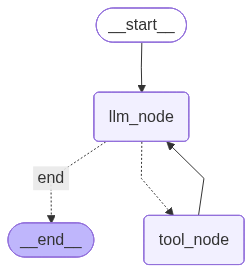

In [16]:
from langgraph.graph import StateGraph, START, END

# Create a StateGraph using the graph schema.
# The schema defines the structure of the shared state
# that will be passed between all nodes.
graph = StateGraph(graph_schema)

# =========================
# Add Nodes
# =========================

# LLM Node:
# Responsible for reasoning and deciding whether a tool is needed.
graph.add_node("llm_node", llm_node)

# Tool Node:
# Executes tool calls generated by the LLM and stores
# tool outputs as ToolMessages in the graph state.
graph.add_node("tool_node", tool_node)

# =========================
# Add Edges
# =========================

# Start the workflow by executing the LLM node.
graph.add_edge(START, "llm_node")

# Conditional Routing:
# After the LLM node executes, inspect the latest AIMessage.
#
# if_tool_call() returns:
# - "tool_node" → if the LLM generated tool_calls
# - "end"       → if no tool is needed
#
# Routing Table:
# "tool_node" → Tool Node
# "end"       → END
# add_conditional_edges(
#     source_node,        # Node after which the condition should be evaluated
#     condition_function, # Function that inspects the state and returns a routing key
#     routing_map         # Dictionary mapping routing keys to destination nodes
# )

graph.add_conditional_edges(
    "llm_node",           # Source node
    if_tool_call,         # Condition function
    {
        "tool_node": "tool_node",  # Route to Tool Node
        "end": END                 # Route to END
    }
)

# After tool execution, return to the LLM node.
# The LLM will read the ToolMessages and generate
# either another tool call or the final answer.
graph.add_edge("tool_node", "llm_node")

# Direct path to END when no tool call is required.
# (Used when the LLM already knows the answer.)
graph.add_edge("llm_node", END)

# =========================
# Compile Graph
# =========================

# Validate nodes, edges, and state transitions,
# then convert the graph definition into a runnable workflow.
react_graph = graph.compile()

# =========================
# Visualize Graph
# =========================

from IPython.display import Image, display

# Generate and display a Mermaid diagram of the graph.
# Useful for understanding and debugging workflow execution.
Image(
    react_graph.get_graph().draw_mermaid_png()
)

### **Graph Invocation**

In [19]:
react_graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'search_duckduckgo', 'arguments': '{"query": "latest news on AI"}'}, '__gemini_function_call_thought_signatures__': {'8022fd6c-28fc-4399-a2be-d38edaf80230': 'CuYBAQw51sdG0fO7X1yHQQ1gskKWn7vpQ0ndjc+9kaCEV+Udn3qqjW/hkZ12jMJdGV/ahN5YB3S83ysvLN0BHVvhqGvWs18MoHieA8bP0WnvnjzazK37KGgPpUX+0WN6oD6/gZ9hw8QD9opG7CFzI0kjRyWvPP1f0bLhSpckOLLduVuGb7BN/e9OBqii0SJam+u22fv3wUmfgqNbfWTR/pXpmRpmKm/sSnGzM4HTFon5vXZ1tA0UXMmYJ2pDtvIPDPGjE4x4ZTHP0Tb5BSLlhbJs9lb4SAk+LUzQ09cXtVQdJTR2FLuWi8g='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ef07f-62dc-7ea2-b6a6-e23ee1d6992c-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'latest news on AI'}, 'id': '8022fd6c-28fc-4399-a2be-d38edaf80230', 'type': 'tool_call'}], inv

In [ ]:
# Start graph execution with the initial state.
# Here we provide the first HumanMessage that will be processed by the agent.
for chunk in react_graph.stream(
    
    {
        "messages": [
            HumanMessage(
                content="What is the latest news on AI?"
            )
        ]
    },

    # stream_mode="updates" returns the output/state update
    # generated by each node as the graph executes.
    #
    # Example flow:
    # HumanMessage
    #      ↓
    # LLM Node Output
    #      ↓
    # Tool Node Output
    #      ↓
    # Final LLM Output
    stream_mode="updates"
):

    # Print the state update produced by each node.
    # Useful for debugging and understanding how the graph
    # executes step-by-step.
    print(chunk)
    